<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/rna-seq/08_durusma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Duruşma: PyDESeq2 ile diferansiyel ifade

Yedinci rehberin avında bulduğunuz genin adı açıklanıyor: **Ahsp**. Serbest alfa-globin zincirlerini çökelmeden tutan eritroid bir şaperon — yani dördüncü ve altıncı rehberlerin gürültücü yıldızı Hba-a1'in bakıcısı. Nakavt farelerde susturulan gen bu; kan fabrikasından sıradan bir işçi değil, montaj hattının ustabaşı sökülmüş. Bu defterde sorumuz şu: istatistik bu sökümü görüyor mu ve onunla birlikte başka kimleri mahkûm ediyor?

Bir not: model uydurma bir-iki dakika sürer; hücreyi başlatın, kahvenizi alın.

In [1]:
%pip install -q pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==

## 1. Dava dosyası

Altıncı rehberin kapanışını aynen devralıyoruz: gen düzeyi tablo, toplamı 10'un altındaki sessiz genlerin elenmesi ve her örneğin grubunu söyleyen künye.

In [2]:
import pandas as pd
import numpy as np

t = pd.read_csv('https://raw.githubusercontent.com/melissa-04/melisayla-biyoinformatik/main/data/rna-seq/sayim_tablosu.csv')
ornekler = ['WT_1', 'WT_2', 'WT_3', 'KO_1', 'KO_2', 'KO_3']
g = t.set_index('gen_id')[ornekler]

sayim = g.T
sayim = sayim[sayim.columns[sayim.sum(axis=0) >= 10]]
meta = pd.DataFrame({'genotip': ['WT'] * 3 + ['KO'] * 3}, index=sayim.index)
print('Dava dosyası:', sayim.shape[1], 'gen ×', sayim.shape[0], 'örnek')

Dava dosyası: 21994 gen × 6 örnek


## 2. Model: iki satır kod, iki paragraf fikir

Grup başına üç örnekle bir genin varyansını tek başına kestiremezsiniz; DESeq2'nin asıl marifeti, binlerce genin bilgisini birleştirip her genin varyansını (dispersiyonunu) komşularından ödünç akılla kestirmesi. Sayım verisinin doğasına uyan negatif binom dağılımını kullanır; bu yüzden ona **ham sayım** verilir, normalize tablo değil — cetveli kendisi kurar.

`ref_level` ile WT'yi referans ilan ediyoruz: bundan sonra bütün kat değişimleri "KO, WT'ye göre" diye okunacak.

In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(counts=sayim, metadata=meta,
                   design="~genotip", ref_level=["genotip", "WT"], quiet=True)
dds.deseq2()
print('Model uydu.')

/tmp/ipykernel_757/2828897201.py:4: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=sayim, metadata=meta,


Model uydu.


## 3. Cetvellerin yüzleşmesi

Geçen rehberde on satır pandas ile bir cetvel kurmuştunuz. Şimdi aracın kendi kurduğu cetveli çıkarıp yan yana koyuyoruz. Bakın ve kendi sorunuzu sorun: kara kutu muymuş?

In [4]:
sf_arac = dds.obs["size_factors"] if "size_factors" in dds.obs else pd.Series(
    np.asarray(dds.obsm["size_factors"]).ravel(), index=sayim.index)

poz = g[(g > 0).all(axis=1)]
logg = np.log(poz)
sf_el = np.exp(logg.sub(logg.mean(axis=1), axis=0).median(axis=0))

print(pd.DataFrame({'el (Rehber 7)': sf_el.round(2), 'PyDESeq2': np.round(sf_arac, 2)}))

      el (Rehber 7)  PyDESeq2
WT_1           0.76      0.76
WT_2           0.63      0.63
WT_3           1.98      1.98
KO_1           0.88      0.88
KO_2           1.28      1.28
KO_3           0.96      0.96


## 4. Sanığın karnesi

`summary()` her gen için dört sütun döker. **baseMean**: genin normalize ortalama sesi. **log2FoldChange**: kaç kat değişti, log2 dilinde (−1 yarıya inmek, +1 ikiye katlamak). **pvalue**: "hiç fark yokken bu kadar fark görme" olasılığı. **padj**: aynı anda on binlerce duruşma yürüttüğümüz için düzeltilmiş hali — 0,05 eşiğiyle yaklaşık 16.800 testte 840 civarı yalancı mahkûmiyet beklersiniz; kararlar bu yüzden pvalue'ya değil padj'ye dayanır. Bazı satırlarda padj'nin NA olması hata değildir: DESeq2, zaten karar verilemeyecek kadar sessiz genlerde düzeltme bütçesini harcamaz.

In [5]:
st = DeseqStats(dds, contrast=["genotip", "KO", "WT"], quiet=True)
st.summary()

sonuc = st.results_df
sonuc['gen_adi'] = t.set_index('gen_id')['gen_adi'].reindex(sonuc.index)

print(sonuc[sonuc.gen_adi == 'Ahsp'][['baseMean', 'log2FoldChange', 'pvalue', 'padj']]
      .to_string(float_format=lambda x: f'{x:.3g}'))

anlamli = sonuc[(sonuc.padj < 0.05) & (sonuc.log2FoldChange.abs() > 1)]
print('\nAnlamlı (padj<0.05 ve |lfc|>1):', len(anlamli),
      '| yükselen:', int((anlamli.log2FoldChange > 0).sum()),
      '| düşen:', int((anlamli.log2FoldChange < 0).sum()))

                      baseMean  log2FoldChange   pvalue     padj
gen_id                                                          
ENSMUSG00000121605.1  4.97e+04           -12.9 1.45e-28 3.47e-26

Anlamlı (padj<0.05 ve |lfc|>1): 1388 | yükselen: 632 | düşen: 756


## 5. Volkan

Binlerce satırlık tabloyu tek bakışta okumanın yolu: her nokta bir gen, yatay eksen "kaç kat" (log2FC), dikey eksen "ne kadar eminiz" (−log10 padj). Kesikli çizgiler eşikler; mor noktalar iki eşiği birden geçenler. Köşelere gidin: sağ üst hem çok yükselen hem kesin, sol üst hem çok düşen hem kesin.

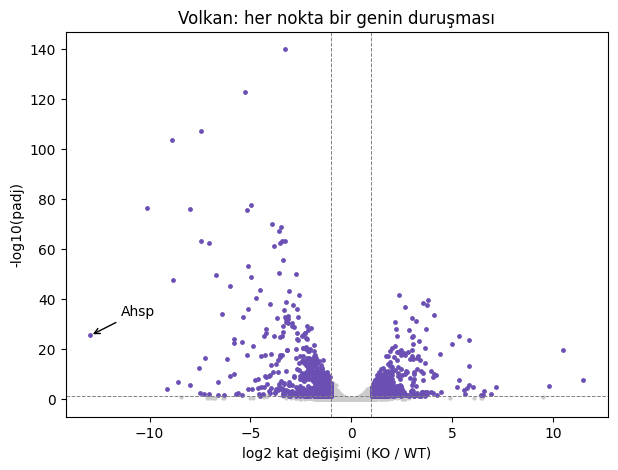

In [6]:
import matplotlib.pyplot as plt

ciz = sonuc.dropna(subset=['padj']).copy()
ciz['y'] = -np.log10(ciz.padj)
onem = (ciz.padj < 0.05) & (ciz.log2FoldChange.abs() > 1)

plt.figure(figsize=(7, 5))
plt.scatter(ciz.log2FoldChange[~onem], ciz.y[~onem], s=4, c='#CCCCCC')
plt.scatter(ciz.log2FoldChange[onem], ciz.y[onem], s=6, c='#6B4FB3')

sanik = ciz[ciz.gen_adi == 'Ahsp'].iloc[0]
plt.annotate('Ahsp', (sanik.log2FoldChange, sanik.y),
             xytext=(sanik.log2FoldChange + 1.5, sanik.y + 8),
             arrowprops=dict(arrowstyle='->'))

plt.axhline(-np.log10(0.05), ls='--', lw=0.7, c='gray')
plt.axvline(-1, ls='--', lw=0.7, c='gray'); plt.axvline(1, ls='--', lw=0.7, c='gray')
plt.xlabel('log2 kat değişimi (KO / WT)'); plt.ylabel('-log10(padj)')
plt.title('Volkan: her nokta bir genin duruşması');

## 6. Kürsü

Sanık mahkûm: volkanın en solundaki nokta o. Ama dikkat: en soldaki nokta en *yüksek* nokta değil. "En büyük etki" ile "en kesin kanıt" iki ayrı sorudur ve volkanın iki ekseni tam da bu yüzden ayrıdır. Kürsüye çıkacak tanıkları size bırakıyorum.

## Kendin dene

Üç görev. Birincisi, sanığın karnesi: kendi koşunuzdan Ahsp'nin log2FoldChange ve padj değerlerini not edin ve `2**12.94` hesabıyla bu kat değişiminin "kaç kat" demek olduğunu tek satırda görün. İkincisi, baş tanık: `sonuc` tablosunu padj'ye göre sıralayın ve kürsüdeki en kesin tanığın adını bulun — sanık mı çıktı? Çıkmadıysa bu size volkanın iki ekseni hakkında ne söylüyor? Üçüncüsü, globin bilmecesinin finali: volkanda Hbb-y ile Hbb-bs'yi bulun, yönlerine ve kesinliklerine bakın, sonra Veri sayfasındaki arındırma notunu yeniden okuyun. Soru şu: Hbb-y ham okumalarda zirvedeyken Hbb-bs tabloda neden dipteydi — ve volkandaki Hbb-bs "mahkûmiyetine" neden ihtiyatla yaklaşmalıyız? Tek cümle yeter; ama o cümle, istatistiğin tek başına neden yetmediğinin özeti olacak.